In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense ,Flatten

In [3]:
# MNIST dataset -> multiclass classification
(X_train,y_train),(X_test,y_test)=keras.datasets.mnist.load_data()

In [4]:
X_train.shape

(60000, 28, 28)

In [5]:
X_train[0].shape

(28, 28)

In [6]:
X_test.shape

(10000, 28, 28)

In [7]:
y_train

array([5, 0, 4, ..., 5, 6, 8], shape=(60000,), dtype=uint8)

In [8]:
# converting digit to image 

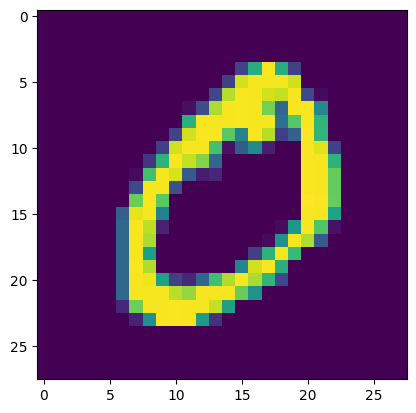

In [9]:
plt.imshow(X_train[1])

In [10]:
# building an ann such that passing this data will train model which digit this is 

In [11]:
X_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

In [12]:
# values inside each image vary from 0-255 -> gotta scale all of them to similar range(0-1) to get better weights and thus fast convergence 
# so dividing all by 255

In [13]:
X_train=X_train/255
X_test=X_test/255

In [14]:
model = Sequential()

In [15]:
# currently the data is in 28*28 i.e. 2d so flatten to bring it down to 1 d

In [16]:
model.add(Flatten(input_shape=(28,28)))
model.add(Dense(128,activation='relu'))
model.add(Dense(10,activation='softmax')) #use softmax when nodes are more than 1 in output layer of classification

C:\Users\Kartik\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
model.compile(loss='sparse_categorical_crossentropy',optimizer='Adam',)

In [19]:
model.fit(X_train,y_train,epochs=10,validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - loss: 0.2824 - val_loss: 0.1534
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - loss: 0.1258 - val_loss: 0.1150
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - loss: 0.0862 - val_loss: 0.1018
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 0.0645 - val_loss: 0.0917
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - loss: 0.0485 - val_loss: 0.0886
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 0.0384 - val_loss: 0.0897
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 0.0302 - val_loss: 0.0943
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - loss: 0.0241 - val_loss: 0.0944
Epoch 9/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - loss: 0.0191 - val_loss: 0.0852
Epoch 10/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 0.0152 - val_loss: 0.0913


In [21]:
y_prob = model.predict(X_test) #will give probability of every digit for each image 

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [27]:
# chooses the max value 
y_pred = y_prob.argmax(axis=1)

In [30]:
from sklearn.metrics import accuracy_score
acc= accuracy_score(y_test,y_pred)
acc

0.9785

In [35]:
# can also plot history -> graphs 

In [36]:
# testing

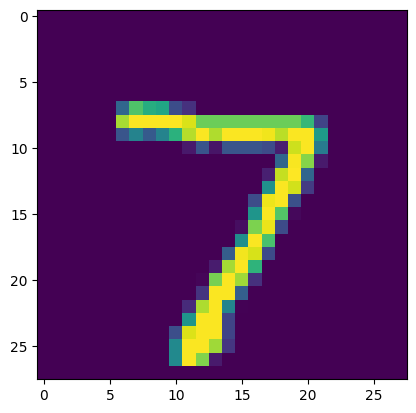

In [37]:
plt.imshow(X_test[0])

In [38]:
model.predict(X_test[0].reshape(1,28,28)).argmax(axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step


array([7])